# Retail Sales — Exploratory Data Analysis

This notebook explores a retail sales transaction dataset (`retail_sales_data.csv`) covering **January 2023 – June 2025**. The goals are to:

1. Understand the shape and quality of the data
2. Summarize key numerical variables
3. Uncover time-based sales trends (monthly / quarterly)
4. Profile customers (age, gender)
5. Identify top products and category-level revenue drivers
6. Examine relationships between numerical variables
7. Surface at least one non-obvious insight
8. Translate findings into concrete business recommendations

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid", palette= 'deep')
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 1. Load Data & Initial Inspection

In [4]:
path = '../data/retail_sales_data.csv'
df = pd.read_csv(path)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 40,855 rows x 16 columns


,Order ID,Order Date,Customer ID,Age,Gender,Segment,Region,City,Product Category,Sub-Category,Product Name,Unit Price,Quantity,Discount,Sales,Profit
0,ORD-025243,2024-08-29,CUST-01643,18.0,Female,Corporate,North,Springfield,Beauty & Personal Care,Skincare,Skincare - Model A,102.99,1,0.00,102.99,44.33
1,ORD-001792,2023-03-01,CUST-00679,43.0,Female,Consumer,West,Marion,Apparel,Men's Shirts,Men's Shirts - Model D,166.44,1,0.00,166.44,43.18
2,ORD-012385,2023-11-22,CUST-00097,20.0,Male,Consumer,East,Salem,Home & Kitchen,Cookware,Cookware - Model A,163.44,1,0.00,163.44,61.61
3,ORD-011611,2023-11-08,CUST-00410,21.0,Male,Corporate,South,Madison,Electronics,Tablets,Tablets - Model B,1025.70,2,0.00,2051.40,884.35
4,ORD-032976,2025-01-08,CUST-01527,53.0,Male,Corporate,West,Fairfax,Home & Kitchen,Storage,Storage - Model B,16.79,1,0.05,15.95,6.37


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40855 entries, 0 to 40854
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          40855 non-null  str    
 1   Order Date        40855 non-null  str    
 2   Customer ID       40855 non-null  str    
 3   Age               40243 non-null  float64
 4   Gender            40855 non-null  str    
 5   Segment           40855 non-null  str    
 6   Region            40855 non-null  str    
 7   City              40855 non-null  str    
 8   Product Category  40855 non-null  str    
 9   Sub-Category      40855 non-null  str    
 10  Product Name      40855 non-null  str    
 11  Unit Price        40855 non-null  float64
 12  Quantity          40855 non-null  int64  
 13  Discount          40529 non-null  float64
 14  Sales             40855 non-null  float64
 15  Profit            40855 non-null  float64
dtypes: float64(5), int64(1), str(10)
memory usage: 5.0 

In [6]:
print("Null values per column: \n")
null_summary = df.isnull().sum().to_frame('nulls')
null_summary['pct_null'] = (null_summary['nulls'] / len(df) * 100).round(2)
null_summary = null_summary[null_summary['nulls'] > 0].sort_values('nulls', ascending= False)
print(null_summary)

Null values per column: 

          nulls  pct_null
Age         612       1.5
Discount    326       0.8


**Observation:** The dataset has 16 columns and ~40.9K transaction-level rows spanning 2023‑01‑01 to 2025‑06‑30. Two columns carry a small amount of missingness — `Age` (~1.5%) and `Discount` (~0.8%) — consistent with real-world POS/CRM exports where optional fields are sometimes left blank. This is low enough that we can impute or drop rows for specific analyses without materially biasing results, but it's worth flagging for a data-quality fix upstream (e.g., enforcing required fields at checkout/CRM entry).

In [7]:
# Light cleaning for downstream analysis: impute missing Age with median, and missing Discount with 0.
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Discount'] = df['Discount'].fillna(0)
df['Age'] = df['Age'].astype(int)




In [8]:
# Derived time features used throughout the notebook
df['Order Date'] = pd.to_datetime(df['Order Date'])
df["Year"] = df["Order Date"].dt.year
df['Month'] = df['Order Date'].dt.month
df['MonthPeriod'] = df['Order Date'].dt.to_period('M').astype(str)
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['ProfitMargin'] = (df['Profit'] / df['Sales']).replace([np.inf, -np.inf], np.nan)

print('Cleaned. Remaining nulls: ', df.isnull().sum().sum())


Cleaned. Remaining nulls:  0


In [9]:
df.dtypes

Order ID                       str
Order Date          datetime64[us]
Customer ID                    str
Age                          int64
Gender                         str
Segment                        str
Region                         str
City                           str
Product Category               str
Sub-Category                   str
Product Name                   str
Unit Price                 float64
Quantity                     int64
Discount                   float64
Sales                      float64
Profit                     float64
Year                         int32
Month                        int32
MonthPeriod                    str
Quarter                        str
DayOfWeek                      str
ProfitMargin               float64
dtype: object

## 2. Descriptive Statistics

In [10]:
numeric_cols  = ['Age', 'Unit Price', 'Quantity', 'Discount', 'Sales', 'Profit', 'ProfitMargin']
desc = df[numeric_cols].describe().T
desc['mode'] = df[numeric_cols].mode().iloc[0]
desc = desc.rename(columns= {'25%': 'q1', '50%':'median', '75%' : 'q3'}) 
desc = desc[['count', 'mean', 'median', 'mode', 'std', 'q1', 'q3', 'min', 'max']]
desc.round(2)

,count,mean,median,mode,std,q1,q3,min,max
Age,40855.0,37.45,37.00,18.00,12.10,28.00,45.00,18.00,79.00
Unit Price,40855.0,243.59,128.32,21.59,276.81,55.94,335.76,2.00,1199.82
Quantity,40855.0,1.69,1.00,1.00,0.90,1.00,2.00,1.00,4.00
Discount,40855.0,0.04,0.00,0.00,0.07,0.00,0.05,0.00,0.30
Sales,40855.0,394.01,182.99,27.01,550.20,76.82,461.30,1.78,4770.32
Profit,40855.0,126.44,56.35,8.31,188.09,22.08,146.55,-97.66,2122.93
ProfitMargin,40855.0,0.32,0.32,0.25,0.08,0.27,0.38,-0.07,0.45


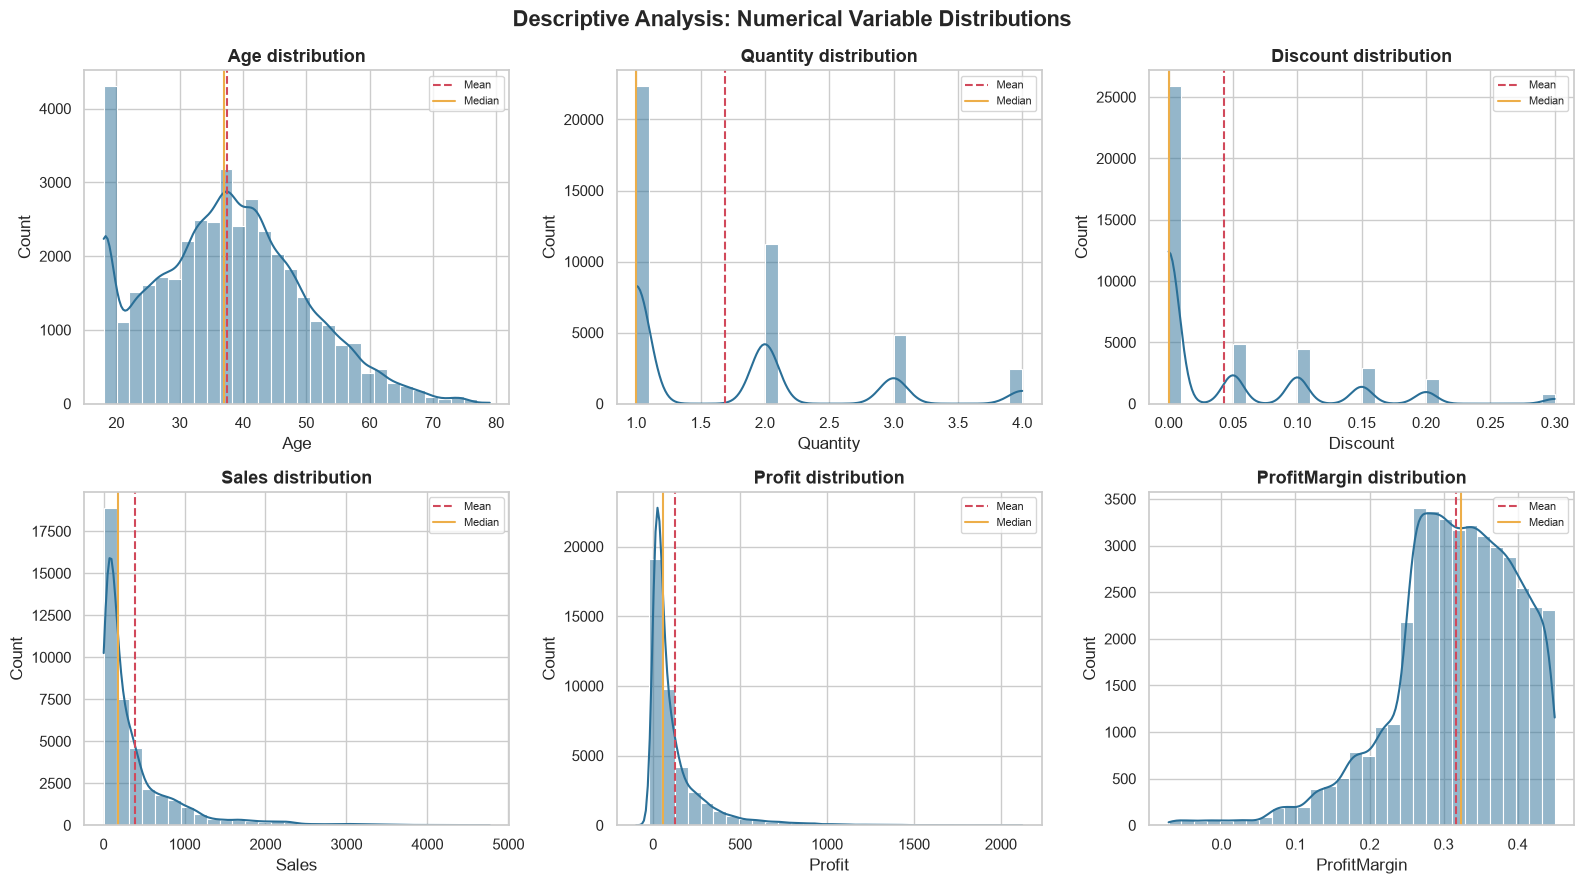

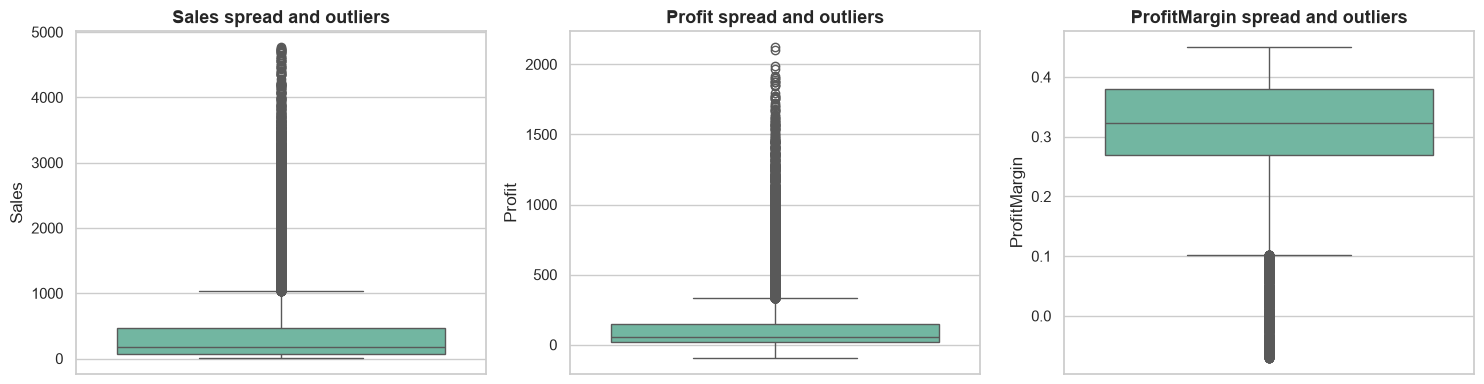

In [11]:
# Visualize the distributions described above.
plot_cols = ['Age', 'Quantity', 'Discount', 'Sales', 'Profit', 'ProfitMargin']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, column in zip(axes, plot_cols):
    sns.histplot(df[column].dropna(), bins=30, kde=True, ax=ax, color='#2a6f97')
    ax.axvline(df[column].mean(), color='#d1495b', linestyle='--', linewidth=1.5, label='Mean')
    ax.axvline(df[column].median(), color='#edae49', linestyle='-', linewidth=1.5, label='Median')
    ax.set_title(f'{column} distribution')
    ax.set_xlabel(column)
    ax.legend(fontsize=8)

fig.suptitle('Descriptive Analysis: Numerical Variable Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, ['Sales', 'Profit', 'ProfitMargin']):
    sns.boxplot(y=df[column], ax=ax, color='#66c2a5')
    ax.set_title(f'{column} spread and outliers')
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()

**Observation:**
- **Sales per line item** average ~\$394 but the median (~\$180) is much lower than the mean, and the max is far higher — a classic right-skewed distribution driven by a smaller number of high-ticket Electronics/Furniture orders.
- **Quantity** is almost always 1–2 units per order line, typical of a non-bulk retail/e-commerce channel.
- **Discount** has a mode of 0 — most transactions are sold at full price, with discounting reserved for a meaningful minority of orders.
- **Profit margin** clusters in a plausible 20–35% band, but with a long left tail, meaning some transactions are sold near break-even (likely the heavily discounted, low-margin items).


## 3. Time Series Analysis -- Monthly & Quarterly Trends

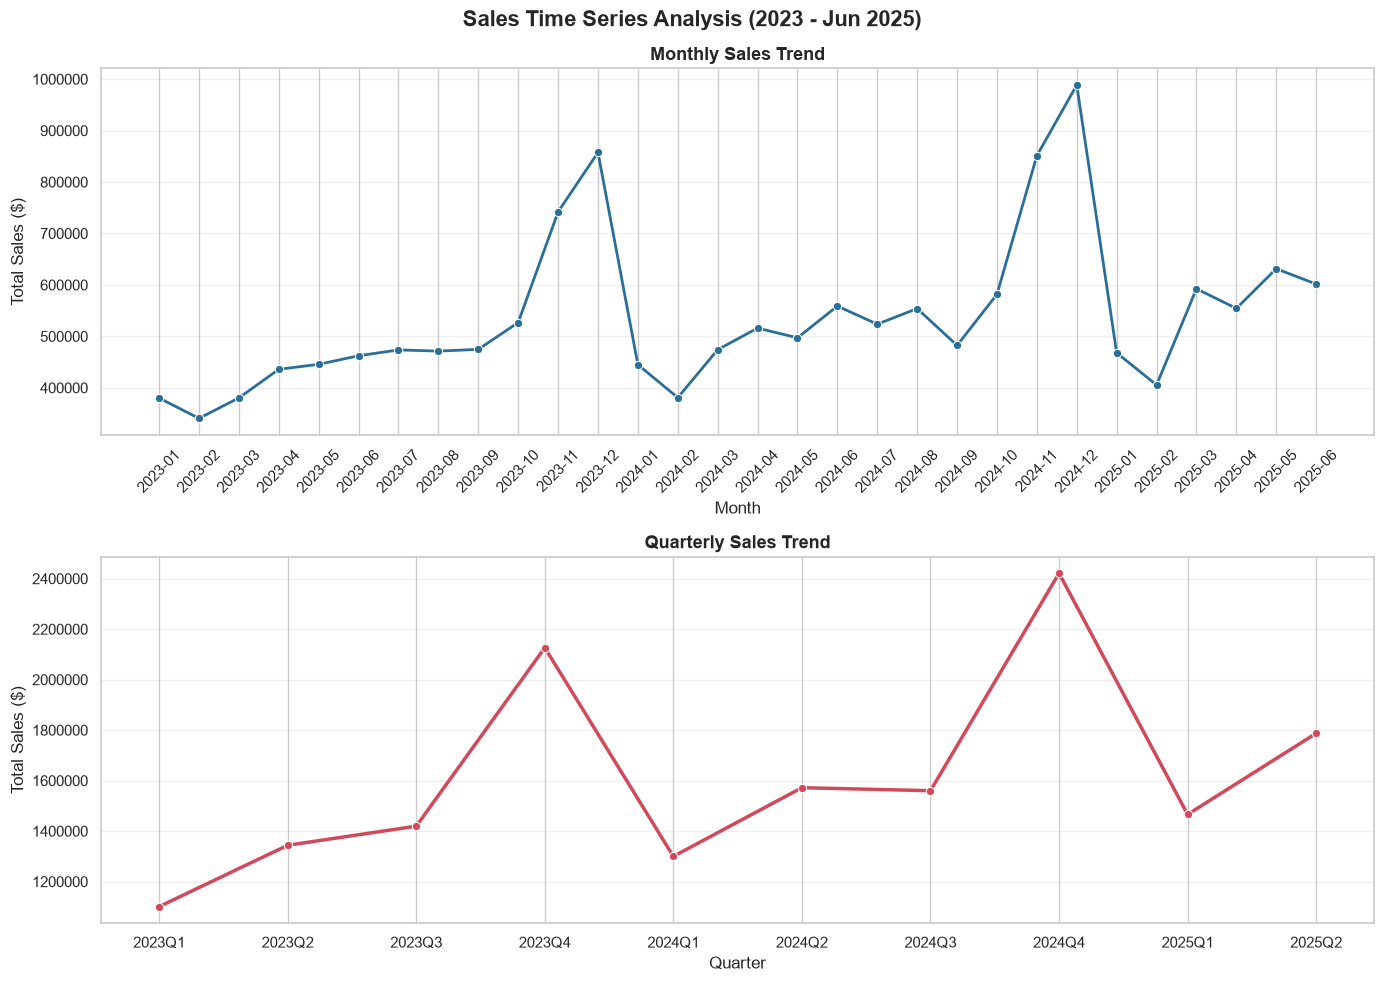

In [20]:
# Aggregate sales by month 
monthly_sales = (
    df.groupby('MonthPeriod', as_index=False)['Sales']
      .sum()
      .rename(columns={'Sales': 'Total Sales'})
)
monthly_sales['Sales Growth (%)'] = monthly_sales['Total Sales'].pct_change().mul(100)

# Aggregate sales by quarter
quarterly_sales = (
    df.groupby('Quarter', as_index=False)['Sales']
      .sum()
      .rename(columns={'Sales': 'Total Sales'})
)
quarterly_sales['Sales Growth (%)'] = quarterly_sales['Total Sales'].pct_change().mul(100)

#print('Monthly sales:')
#display(monthly_sales.round(2))
#print('Quarterly sales:')
#display(quarterly_sales.round(2))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Monthly sales trend
sns.lineplot(
    data=monthly_sales,
    x='MonthPeriod',
    y='Total Sales',
    marker='o',
    linewidth=2,
    color='#2a6f97',
    ax=axes[0]
)
axes[0].set_title('Monthly Sales Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=45)

# Quarterly sales trend
sns.lineplot(
    data=quarterly_sales,
    x='Quarter',
    y='Total Sales',
    marker='o',
    linewidth=2.5,
    color='#d1495b',
    ax=axes[1]
)
axes[1].set_title('Quarterly Sales Trend')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Total Sales ($)')

# Format y-axis labels and add grid
for ax in axes:
    ax.ticklabel_format(style='plain', axis='y')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Sales Time Series Analysis (2023 - Jun 2025)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:**
- Sales show a clear upward pattern through much of each year, followed by a strong seasonal peak in the final quarter. November and December are consistently the strongest months, with December reaching the highest monthly sales in both 2023 and 2024.
- Sales decline sharply in January and February after the holiday peak. January sales fell by approximately 48% in 2024 and 53% in 2025 compared with the preceding December, indicating a strong post-holiday slowdown.
- Quarterly results confirm that Q4 is the strongest quarter: sales increased from approximately $2.13 million in 2023 Q4 to $2.42 million in 2024 Q4. Q1 is consistently the weakest quarter, followed by recovery in Q2 and Q3.
- The business should prepare inventory and marketing capacity for the October–December peak, while using targeted promotions and customer-retention campaigns to reduce the recurring January–February decline.


## 4. Customer Demographics Analysis

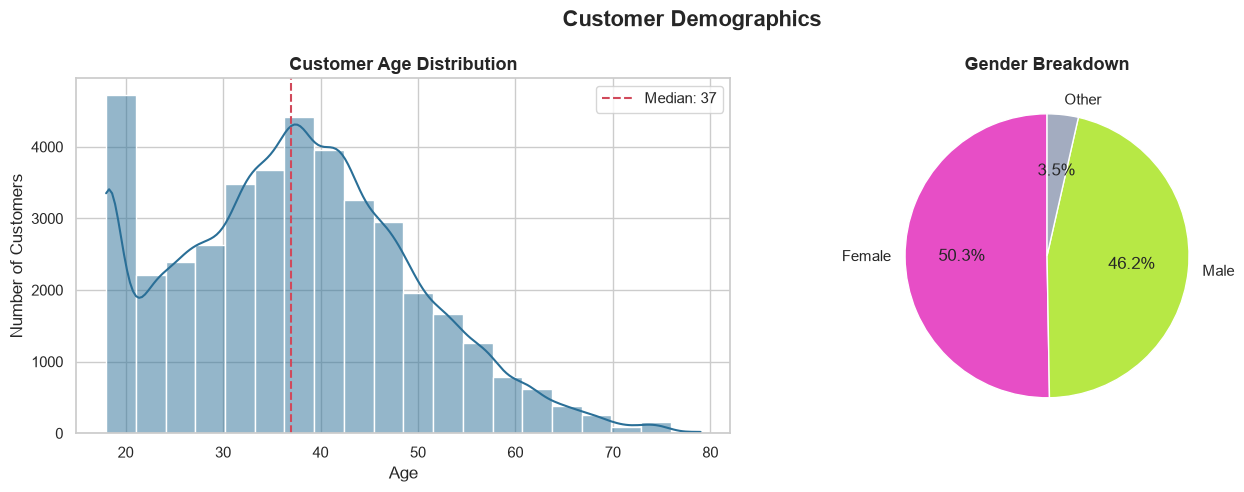

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
sns.histplot(df['Age'].dropna(), bins=20, kde=True, color='#2a6f97', ax=axes[0])
axes[0].axvline(df['Age'].median(), color='#d1495b', linestyle='--', linewidth=1.5, label=f"Median: {df['Age'].median():.0f}")
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Gender breakdown
_gender_counts = df['Gender'].value_counts(dropna=False)
_gender_labels = _gender_counts.index.astype(str).where(~_gender_counts.index.isna(), 'Unknown')
axes[1].pie(
    _gender_counts,
    labels=_gender_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=["#e74ec6", "#b7e845", "#a3acc0"],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
axes[1].set_title('Gender Breakdown')

fig.suptitle('Customer Demographics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Age-group segmentation:


,Age Group,Customers,Average Sales,Total Sales,Share (%)
0,18-24,6925,399.00,2763043.37,17.0
1,25-34,9717,391.36,3802809.73,23.8
2,35-44,13161,394.05,5186044.20,32.2
3,45-54,7494,394.01,2952715.65,18.3
4,55-64,2787,396.96,1106327.94,6.8
5,65+,771,371.16,286167.08,1.9


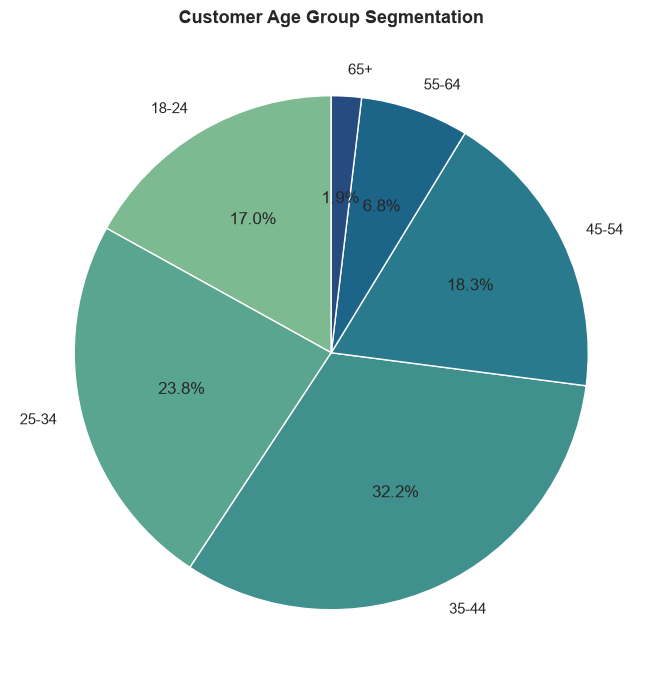

In [ ]:
# Business-friendly customer age segments.
age_bins = [17, 24, 34, 44, 54, 64, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age Group'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

age_group_summary = (
    df.groupby('Age Group', observed=False)
      .agg(
          Customers=('Age', 'size'),
          **{
              'Average Sales': ('Sales', 'mean'),
              'Total Sales': ('Sales', 'sum')
          }
      )
      .reset_index()
)
age_group_summary['Share (%)'] = (
    age_group_summary['Customers'] / age_group_summary['Customers'].sum() * 100
).round(1)
age_group_summary['Average Sales'] = age_group_summary['Average Sales'].round(2)
age_group_summary['Total Sales'] = age_group_summary['Total Sales'].round(2)

print('Age-group segmentation:')
display(age_group_summary)

plt.figure(figsize=(9, 7))
plt.pie(
    age_group_summary['Customers'],
    labels=age_group_summary['Age Group'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('crest', n_colors=len(age_group_summary)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
plt.title('Customer Age Group Segmentation')
plt.tight_layout()
plt.show()

**Observation:**
- The **35-44 age group** is the largest customer segment, representing **32.2%** of transactions and generating approximately **$5.19 million** in total sales. This group should be the primary target for retention campaigns, loyalty programs, and personalized offers.
- The **25-34 age group** is the second-largest segment at **23.8%**, contributing approximately **$3.80 million** in sales. Digital marketing, social campaigns, and product recommendations may help increase engagement with this segment.
- Customers aged **18-24 and 45-54** contribute meaningful sales shares of **17.0%** and **18.3%**, respectively, so both groups represent important secondary markets.
- Average sales per transaction are relatively consistent across most age groups, ranging from approximately **$391 to $399**. This indicates that the main sales difference comes from customer volume rather than substantially different transaction values.
- The **65+ segment** is the smallest at **1.9%**, generates approximately **$286 thousand** in total sales, and has the lowest average sale at **$371.16**. This group may require more focused outreach, accessible communication, and tailored product offers to grow its contribution.


## 5. Product Analysis

Top 10 best-selling products by revenue:


,Rank,Product Name,Product Category,Units Sold,Transactions,Total Revenue,Average Transaction Revenue
0,1,Smartphones - Model D,Electronics,692,393,417237.72,1061.67
1,2,Headphones - Model D,Electronics,681,393,399654.86,1016.93
2,3,Tablets - Model B,Electronics,663,413,392240.61,949.74
3,4,Cameras - Model D,Electronics,649,391,391465.24,1001.19
4,5,Smartphones - Model A,Electronics,630,384,388480.60,1011.67
5,6,Laptops - Model B,Electronics,624,382,386843.21,1012.68
6,7,Smartwatches - Model C,Electronics,636,386,385660.34,999.12
7,8,Cameras - Model A,Electronics,644,377,384736.29,1020.52
8,9,Headphones - Model C,Electronics,624,369,381447.70,1033.73
9,10,Tablets - Model D,Electronics,634,382,379577.27,993.66


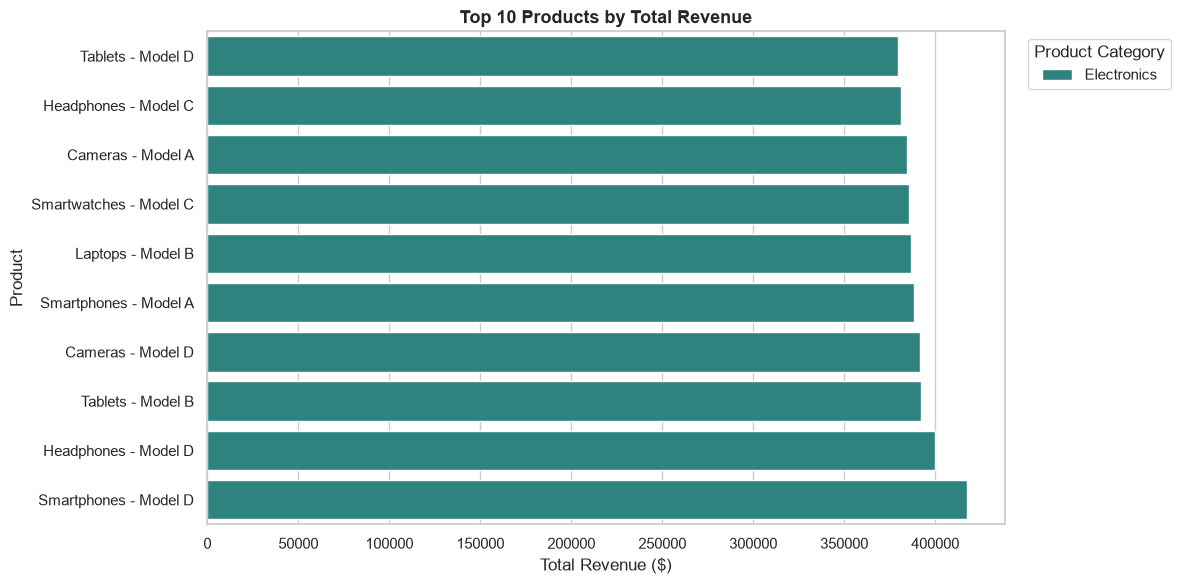

In [15]:
# Identify the top 10 products by total revenue.
top_products = (
    df.groupby(['Product Name', 'Product Category'], as_index=False)
      .agg(**{
          'Units Sold': ('Quantity', 'sum'),
          'Transactions': ('Product Name', 'size'),
          'Total Revenue': ('Sales', 'sum'),
          'Average Transaction Revenue': ('Sales', 'mean')
      })
      .sort_values('Total Revenue', ascending=False)
      .head(10)
      .reset_index(drop=True)
)

top_products.insert(0, 'Rank', range(1, len(top_products) + 1))
top_products['Total Revenue'] = top_products['Total Revenue'].round(2)
top_products['Average Transaction Revenue'] = top_products['Average Transaction Revenue'].round(2)

print('Top 10 best-selling products by revenue:')
display(top_products)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_products.sort_values('Total Revenue'),
    x='Total Revenue',
    y='Product Name',
    hue='Product Category',
    palette='viridis'
)
plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product')
plt.ticklabel_format(style='plain', axis='x')
plt.legend(title='Product Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Revenue by product category:


,Rank,Product Category,Units Sold,Transactions,Total Revenue,Average Transaction Revenue,Revenue Share (%)
0,1,Electronics,15117,8960,9034775.32,1008.35,56.1
1,2,Home & Kitchen,12342,7317,2717983.75,371.46,16.9
2,3,Sports & Outdoors,8387,4920,2027886.18,412.17,12.6
3,4,Apparel,16441,9779,1526082.00,156.06,9.5
4,5,Beauty & Personal Care,9857,5819,588076.69,101.06,3.7
5,6,Groceries,6887,4060,202304.03,49.83,1.3


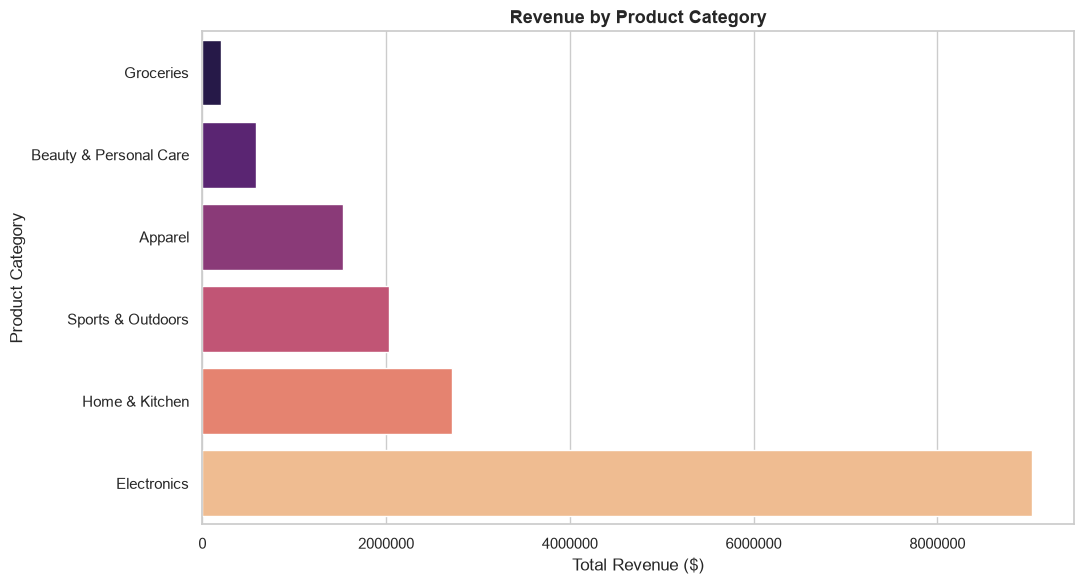

In [16]:
# Analyze revenue by product category.
category_revenue = (
    df.groupby('Product Category', as_index=False)
      .agg(**{
          'Units Sold': ('Quantity', 'sum'),
          'Transactions': ('Product Category', 'size'),
          'Total Revenue': ('Sales', 'sum'),
          'Average Transaction Revenue': ('Sales', 'mean')
      })
      .sort_values('Total Revenue', ascending=False)
      .reset_index(drop=True)
)

category_revenue.insert(0, 'Rank', range(1, len(category_revenue) + 1))
category_revenue['Revenue Share (%)'] = (
    category_revenue['Total Revenue'] / category_revenue['Total Revenue'].sum() * 100
).round(1)
category_revenue['Total Revenue'] = category_revenue['Total Revenue'].round(2)
category_revenue['Average Transaction Revenue'] = category_revenue['Average Transaction Revenue'].round(2)

print('Revenue by product category:')
display(category_revenue)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=category_revenue.sort_values('Total Revenue'),
    x='Total Revenue',
    y='Product Category',
    hue='Product Category',
    palette='magma',
    legend=False
)
plt.title('Revenue by Product Category')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Category')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

**Observation:**
- **Electronics** is the dominant revenue category, generating approximately **$9.03 million**, or **56.1%** of total revenue. It also has the highest average transaction revenue at approximately **$1,008**, showing that higher-priced products are the main revenue drivers.
- All **top 10 products by revenue** belong to the Electronics category. **Smartphones - Model D** ranks first with approximately **$417 thousand** in revenue, followed by **Headphones - Model D** at approximately **$400 thousand**.
- The remaining top products generate between approximately **$380 thousand and $392 thousand** each, indicating strong and relatively balanced demand across several Electronics product lines rather than dependence on only one product.
- **Home & Kitchen** is the second-largest category, contributing approximately **$2.72 million**, or **16.9%** of revenue. **Sports & Outdoors** contributes **12.6%**, while Apparel contributes **9.5%**.
- **Apparel has the highest unit volume** with **16,441 units sold**, but its revenue share is only **9.5%** and its average transaction revenue is approximately **$156**. This shows that high sales volume does not necessarily produce high revenue when products have lower prices.
- **Groceries** contributes the lowest revenue at approximately **$202 thousand**, or **1.3%**, with the lowest average transaction revenue at approximately **$49.83**.
- The business should protect inventory availability for leading Electronics products, use cross-selling to increase Home & Kitchen and Sports & Outdoors revenue, and review pricing or premium product opportunities in high-volume, lower-value categories such as Apparel.


## 6. Correlation Heatmap

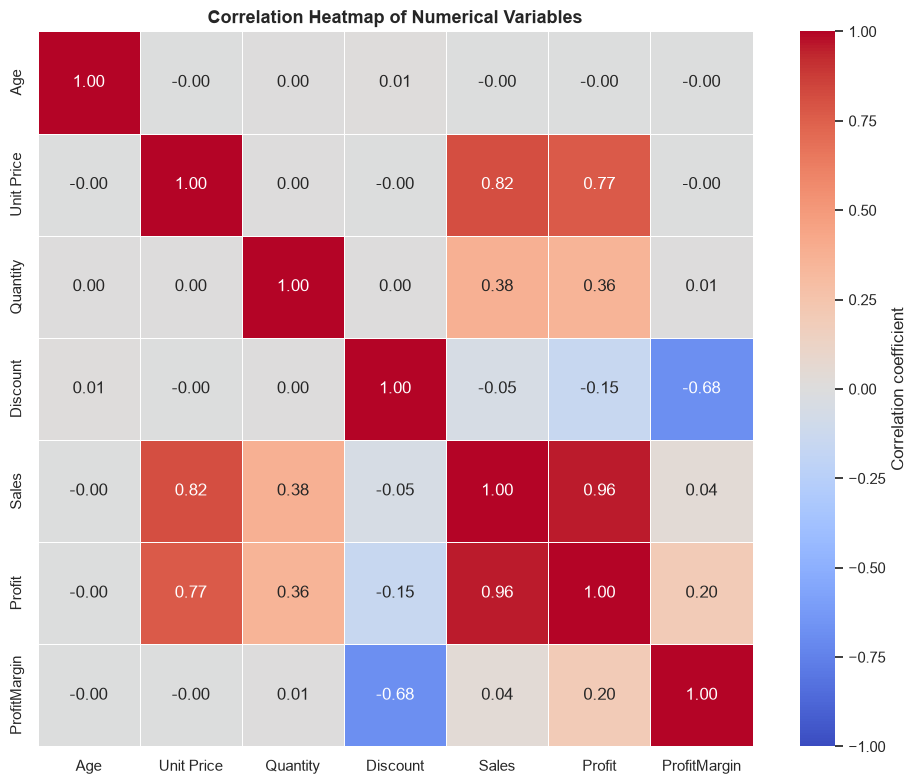

In [17]:
corr_cols = ['Age', 'Unit Price', 'Quantity', 'Discount', 'Sales', 'Profit', 'ProfitMargin']
correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation coefficient'}
)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

**Observation:**
- **Sales and Profit** have a very strong positive correlation of **0.96**, which indicates that higher-revenue transactions generally generate higher absolute profit.
- **Unit Price** is strongly positively correlated with **Sales (0.82)** and **Profit (0.77)**. Higher-priced products are therefore important drivers of both revenue and profit.
- **Quantity** has a moderate positive relationship with **Sales (0.38)** and **Profit (0.36)**. Selling more units contributes to performance, but unit price appears to have a stronger relationship with revenue and profit.
- **Discount** has a strong negative correlation with **ProfitMargin (-0.68)**, suggesting that heavier discounting is associated with lower margins. Its relationship with total Sales is weakly negative (**-0.05**), so discounts do not appear to substantially increase overall sales in this dataset.
- **ProfitMargin** has only a weak positive relationship with **Profit (0.20)** and almost no relationship with **Sales (0.04)**. High sales volume does not automatically translate into a high profit margin.
- **Age** has near-zero correlations with the financial variables, indicating that customer age alone does not explain differences in price, sales, profit, or margin.
- Correlation measures association, not causation. Product category, product mix, seasonality, and discount strategy should be examined alongside these results before making pricing or promotional decisions.


## 7. Additional Insight — Discounting Behavior by Day of Week and Its Margin Impact

,DayOfWeek,Transactions,Discounted_Transactions,Average_Discount,Average_Profit_Margin,Total_Sales,Total_Profit,Discounted Share (%)
0,Monday,5013,1888,4.48,31.53,1947513.16,624110.90,37.66
1,Tuesday,4750,1750,4.35,31.56,1881606.96,601669.54,36.84
2,Wednesday,4992,1807,4.27,31.74,1974266.95,637718.48,36.20
3,Thursday,5258,1921,4.25,31.49,2071383.46,660039.24,36.53
4,Friday,6517,2424,4.43,31.51,2571686.17,825660.93,37.20
5,Saturday,7497,2654,4.10,31.84,2935335.32,942083.67,35.40
6,Sunday,6828,2526,4.32,31.61,2715315.95,874299.66,36.99


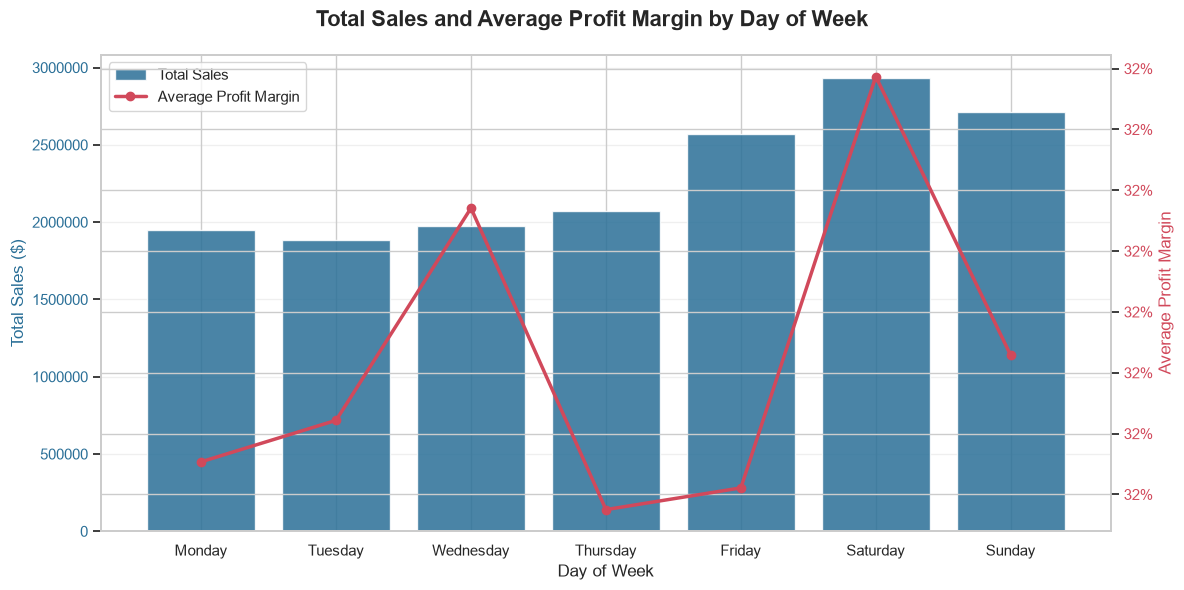

In [18]:
# Analyze discounting behavior by day of week and its margin impact.
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

discount_by_day = (
    df.groupby('DayOfWeek', as_index=False)
      .agg(
          Transactions=('Order ID', 'size'),
          Discounted_Transactions=('Discount', lambda x: (x > 0).sum()),
          Average_Discount=('Discount', 'mean'),
          Average_Profit_Margin=('ProfitMargin', 'mean'),
          Total_Sales=('Sales', 'sum'),
          Total_Profit=('Profit', 'sum')
      )
)

discount_by_day['DayOfWeek'] = pd.Categorical(
    discount_by_day['DayOfWeek'],
    categories=day_order,
    ordered=True
)

discount_by_day['Discounted Share (%)'] = (
    discount_by_day['Discounted_Transactions']
    / discount_by_day['Transactions'] * 100
)

discount_by_day = (
    discount_by_day
    .sort_values('DayOfWeek')
    .reset_index(drop=True)
)

display(
    discount_by_day.assign(
        Average_Discount=lambda x: (x['Average_Discount'] * 100).round(2),
        Average_Profit_Margin=lambda x: (x['Average_Profit_Margin'] * 100).round(2),
        Total_Sales=lambda x: x['Total_Sales'].round(2),
        Total_Profit=lambda x: x['Total_Profit'].round(2),
        **{
            'Discounted Share (%)': lambda x: x['Discounted Share (%)'].round(2)
        }
    )
)

plot_data = (
    discount_by_day
    .set_index('DayOfWeek')
    .reindex(day_order)
    .reset_index()
)
x_positions = np.arange(len(day_order))

fig, sales_axis = plt.subplots(figsize=(12, 6))
margin_axis = sales_axis.twinx()

sales_bars = sales_axis.bar(
    x_positions,
    plot_data['Total_Sales'],
    color='#2a6f97',
    alpha=0.85,
    label='Total Sales'
)
margin_line, = margin_axis.plot(
    x_positions,
    plot_data['Average_Profit_Margin'],
    color='#d1495b',
    marker='o',
    linewidth=2.5,
    label='Average Profit Margin'
)

sales_axis.set_xticks(x_positions)
sales_axis.set_xticklabels(day_order)
sales_axis.set_xlabel('Day of Week')
sales_axis.set_ylabel('Total Sales ($)', color='#2a6f97')
margin_axis.set_ylabel('Average Profit Margin', color='#d1495b')
margin_axis.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f'{value:.0%}')
)
sales_axis.tick_params(axis='y', labelcolor='#2a6f97')
margin_axis.tick_params(axis='y', labelcolor='#d1495b')
sales_axis.ticklabel_format(style='plain', axis='y')
sales_axis.grid(axis='y', alpha=0.3)

sales_axis.legend(
    [sales_bars, margin_line],
    ['Total Sales', 'Average Profit Margin'],
    loc='upper left'
)
fig.suptitle(
    'Total Sales and Average Profit Margin by Day of Week',
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

**Observation:**
- Sales volume is strongest at the weekend. **Saturday** generates the highest total sales at approximately **$2.94 million**, followed by **Sunday** at approximately **$2.72 million**. This indicates that weekend customer activity is a major revenue driver.
- **Friday** is the strongest weekday, generating approximately **$2.57 million** in sales. **Tuesday** has the lowest total sales at approximately **$1.88 million**, followed closely by Monday.
- Average profit margin remains relatively stable across the week, ranging from approximately **31.49% to 31.84%**. **Saturday** has the highest average margin at **31.84%**, while **Thursday** has the lowest at **31.49%**.
- The small variation in profit margin compared with the much larger variation in sales volume suggests that differences in revenue are mainly driven by transaction activity and customer traffic, not by major changes in profitability.
- The business should ensure sufficient inventory and staffing for Friday through Sunday, while using targeted promotions on Monday and Tuesday to increase sales without unnecessarily reducing profit margins.


## 8. Conclusion & Business Recommendations

**Conclusion:**

The analysis shows a profitable retail business with strong seasonal demand, a clear dependence on `Electronics` revenue, and meaningful opportunities to improve `sales` during low-demand periods. Revenue is concentrated in higher-priced products, while customer volume is concentrated in the `25-44` age groups. Sales volume is strongest from Friday through Sunday, but profit margins remain broadly stable across the week.

**Business Recommendations:**

1. **Protect and grow the Electronics category.** Electronics generates approximately **56.1% of total revenue**, and all top 10 products by revenue belong to this category. Maintain strong availability for leading smartphones, headphones, tablets, cameras, laptops, and smartwatches, while using product bundles and accessories to increase basket value.

2. **Plan inventory and marketing around seasonality.** Sales peak in `November` and `December`, while `January and February` show a recurring post-holiday decline. Build inventory and campaign capacity before Q4, then use targeted January-February promotions, loyalty offers, and replenishment campaigns to maintain demand after the holiday period.

3. **Prioritize the 25-44 customer segments.** Customers aged **35-44** are the largest segment and generate the greatest total sales, followed by the **25-34** group. Use personalized recommendations, loyalty benefits, and retention campaigns for these high-value audiences, while testing tailored offers for smaller age groups.

4. **Increase revenue from high-volume, lower-value categories.** `Apparel` sells the highest number of units but contributes a much smaller revenue share because its average transaction value is low. Test premium product lines, bundles, cross-selling, and selective price optimization in Apparel. Similar cross-selling opportunities exist in `Home & Kitchen` and `Sports & Outdoors`.

5. **Use weekday traffic strategically.** `Friday` through `Sunday` generate the highest `sales` volume, so staffing, inventory, and service capacity should be strongest during these days. Use targeted Monday and Tuesday promotions to increase traffic while protecting the approximately 31% average profit margin.

6. **Control discounting to protect margins.** `Discounting` has a **strong negative** relationship with `profit margin` but only a weak relationship with total sales. Replace broad discounts with targeted, product-specific offers and monitor incremental revenue, margin, and repeat purchases before expanding promotions.

7. **Manage for both revenue and profitability.** `Sales`, `Profit`, and `Unit Price` are strongly related, but high sales do not automatically produce a high profit margin. Track revenue, absolute profit, profit margin, discount rate, and customer retention together when evaluating products and campaigns.

8. **Establish ongoing performance monitoring.** Review monthly and quarterly sales, category revenue share, top-product availability, age-group performance, weekday sales, and discount impact through a recurring dashboard. This will help identify changes in demand early and measure whether recommendations improve both growth and profitability.
